In [2]:
import pandas as pd

df = pd.read_csv("bike_sharing_hourly.csv")
(df['casual'] + df['registered'] == df['cnt']).mean()


1.0

In [3]:
df[['casual', 'registered', 'cnt']].describe()

,casual,registered,cnt
count,17379.000000,17379.000000,17379.000000
mean,35.676218,153.786869,189.463088
std,49.305030,151.357286,181.387599
min,0.000000,0.000000,1.000000
25%,4.000000,34.000000,40.000000
50%,17.000000,115.000000,142.000000
75%,48.000000,220.000000,281.000000
max,367.000000,886.000000,977.000000


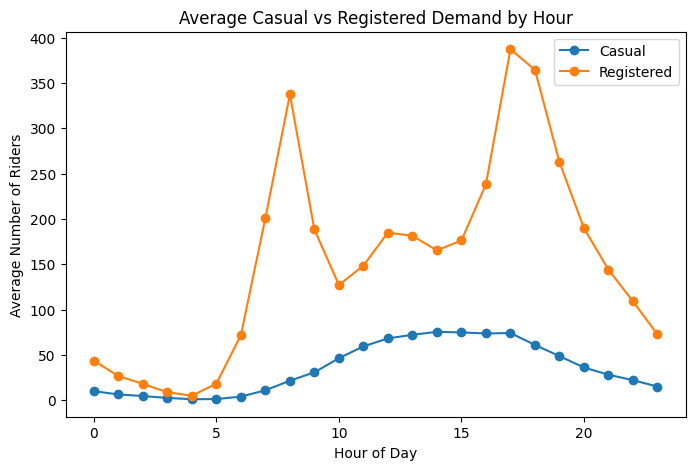

In [4]:
import matplotlib.pyplot as plt

hourly_avg = df.groupby('hr')[['casual', 'registered']].mean()

plt.figure(figsize=(8,5))
plt.plot(hourly_avg.index, hourly_avg['casual'], marker='o', label='Casual')
plt.plot(hourly_avg.index, hourly_avg['registered'], marker='o', label='Registered')
plt.xlabel('Hour of Day')
plt.ylabel('Average Number of Riders')
plt.title('Average Casual vs Registered Demand by Hour')
plt.legend()
plt.show()

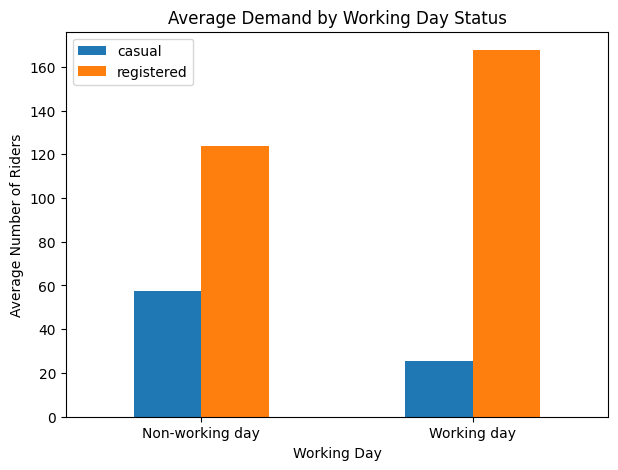

In [6]:
work_avg = df.groupby('workingday')[['casual', 'registered']].mean()

work_avg
work_avg.plot(kind='bar', figsize=(7,5))
plt.xlabel('Working Day')
plt.ylabel('Average Number of Riders')
plt.title('Average Demand by Working Day Status')
plt.xticks([0,1], ['Non-working day', 'Working day'], rotation=0)
plt.show()

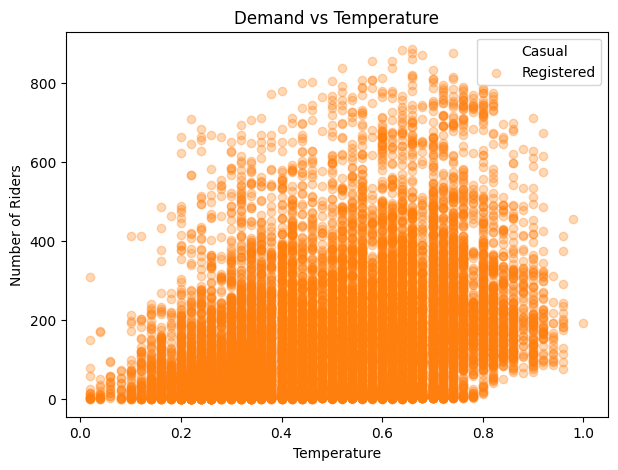

In [9]:
plt.figure(figsize=(7,5))
plt.scatter(df['temp'], df['casual'], alpha=0., label='Casual')
plt.scatter(df['temp'], df['registered'], alpha=0.3, label='Registered')
plt.xlabel('Temperature')
plt.ylabel('Number of Riders')
plt.title('Demand vs Temperature')
plt.legend()
plt.show()

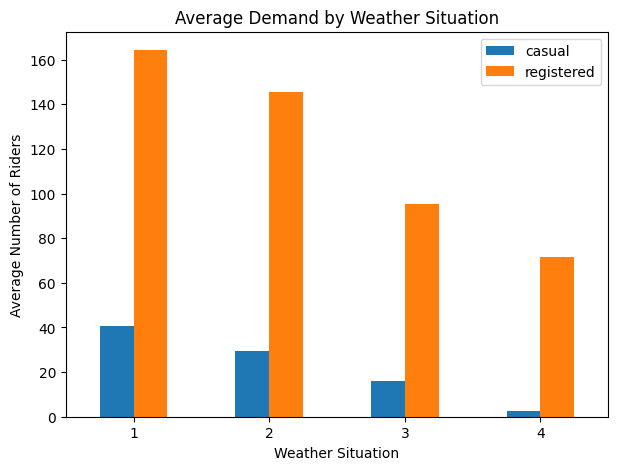

In [10]:
weather_avg = df.groupby('weathersit')[['casual', 'registered']].mean()

weather_avg.plot(kind='bar', figsize=(7,5))
plt.xlabel('Weather Situation')
plt.ylabel('Average Number of Riders')
plt.title('Average Demand by Weather Situation')
plt.xticks(rotation=0)
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
import pandas as pd
features = [
    'season', 'mnth', 'hr', 'holiday', 'weekday',
    'workingday', 'weathersit', 'temp', 'atemp',
    'hum', 'windspeed'
]

X = df[features]
y_casual = df['casual']
y_registered = df['registered']
X_train, X_test, y_casual_train, y_casual_test = train_test_split(
    X, y_casual, test_size=0.25, random_state=0
)

_, _, y_registered_train, y_registered_test = train_test_split(
    X, y_registered, test_size=0.25, random_state=0
)
casual_model = LinearRegression()
casual_model.fit(X_train, y_casual_train)

casual_pred = casual_model.predict(X_test)

casual_r2 = r2_score(y_casual_test, casual_pred)
casual_r2
registered_model = LinearRegression()
registered_model.fit(X_train, y_registered_train)

registered_pred = registered_model.predict(X_test)

registered_r2 = r2_score(y_registered_test, registered_pred)
registered_r2
print("Casual R^2:", casual_r2)
print("Registered R^2:", registered_r2)
coef_compare = pd.DataFrame({
    'feature': features,
    'casual_coef': casual_model.coef_,
    'registered_coef': registered_model.coef_
})

coef_compare

Casual R^2: 0.4444091758517028
Registered R^2: 0.2829903093081696


,feature,casual_coef,registered_coef
0,season,1.948904,17.697750
1,mnth,0.011136,0.264326
2,hr,1.181157,6.336790
3,holiday,-11.192639,-9.709267
4,weekday,0.876383,1.163955
5,workingday,-35.577907,38.872626
6,weathersit,2.280337,-5.316377
7,temp,47.594054,-4.740608
8,atemp,67.689840,208.514589
9,hum,-72.100053,-142.988972


In [16]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_train, X_test, y_casual_train, y_casual_test = train_test_split(
    X_scaled, y_casual, test_size=0.25, random_state=0
)

_, _, y_registered_train, y_registered_test = train_test_split(
    X_scaled, y_registered, test_size=0.25, random_state=0
)

casual_model = LinearRegression()
registered_model = LinearRegression()

casual_model.fit(X_train, y_casual_train)
registered_model.fit(X_train, y_registered_train)

casual_pred = casual_model.predict(X_test)
registered_pred = registered_model.predict(X_test)

print("Casual R^2:", r2_score(y_casual_test, casual_pred))
print("Registered R^2:", r2_score(y_registered_test, registered_pred))
coef_compare = pd.DataFrame({
    'feature': features,
    'casual_coef': casual_model.coef_,
    'registered_coef': registered_model.coef_
})

coef_compare['casual_abs'] = coef_compare['casual_coef'].abs()
coef_compare['registered_abs'] = coef_compare['registered_coef'].abs()

coef_compare.sort_values('casual_abs', ascending=False)

Casual R^2: 0.4444091758517028
Registered R^2: 0.2829903093081696


,feature,casual_coef,registered_coef,casual_abs,registered_abs
5,workingday,-16.558571,18.091990,16.558571,18.091990
9,hum,-13.909851,-27.586045,13.909851,27.586045
8,atemp,11.632179,35.832246,11.632179,35.832246
7,temp,9.164263,-0.912807,9.164263,0.912807
2,hr,8.166765,43.813870,8.166765,43.813870
0,season,2.157215,19.589397,2.157215,19.589397
3,holiday,-1.870967,-1.623006,1.870967,1.623006
4,weekday,1.757773,2.334561,1.757773,2.334561
6,weathersit,1.457907,-3.398965,1.457907,3.398965
10,windspeed,0.434913,4.527925,0.434913,4.527925


In [17]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca_features = [
    'hr', 'workingday', 'temp', 'hum', 'windspeed',
    'casual', 'registered'
]

X_pca = df[pca_features]

scaler = StandardScaler()
X_pca_scaled = scaler.fit_transform(X_pca)

pca = PCA(n_components=2)
Z = pca.fit_transform(X_pca_scaled)

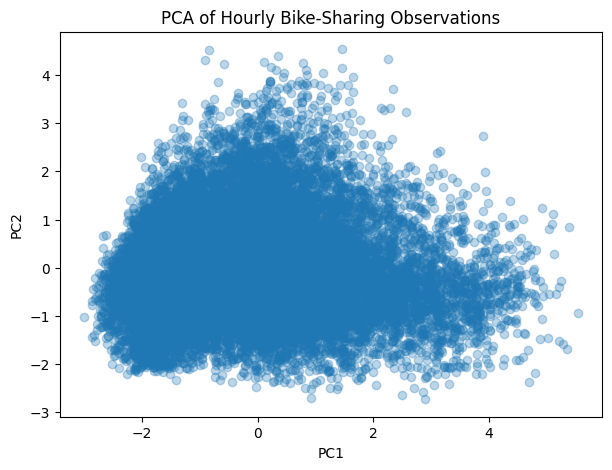

In [18]:
plt.figure(figsize=(7,5))
plt.scatter(Z[:,0], Z[:,1], alpha=0.3)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of Hourly Bike-Sharing Observations')
plt.show()

In [19]:
loadings = pd.DataFrame({
    'feature': pca_features,
    'PC1': pca.components_[0],
    'PC2': pca.components_[1]
})

loadings

,feature,PC1,PC2
0,hr,0.396571,0.154484
1,workingday,-0.061091,-0.043781
2,temp,0.364233,-0.509923
3,hum,-0.384045,-0.456507
4,windspeed,0.186011,0.667473
5,casual,0.531373,-0.185084
6,registered,0.491819,-0.161311
